In [1]:
from Matrix_graph import ws_opinion_graph, create_matrix_rep, GraphState, add_media_nodes_full_normal_dist
from Matrix_simuleringslogik import time_step_no_media_no_disinfo, simpel_simulering, data_processing
import numpy as np
import matplotlib.pyplot as plt

In [2]:
spredningstest =  ws_opinion_graph(1000,15,0.1,seed = 11)

spredningstestmatrix = create_matrix_rep(spredningstest)
mask = spredningstestmatrix.type == 'Human'


In [3]:
spredningstestmatrix.opinions, no_media_no_disinfo_sim_results,no_media_no_disinfo_startcond,no_media_no_disinfo_endcond= simpel_simulering(spredningstestmatrix,200)
average_opinionresult, average_distance_to_the_mean_result = data_processing(no_media_no_disinfo_sim_results,mask)


Simulating: 100%|██████████| 200/200 [00:00<00:00, 710.81it/s]


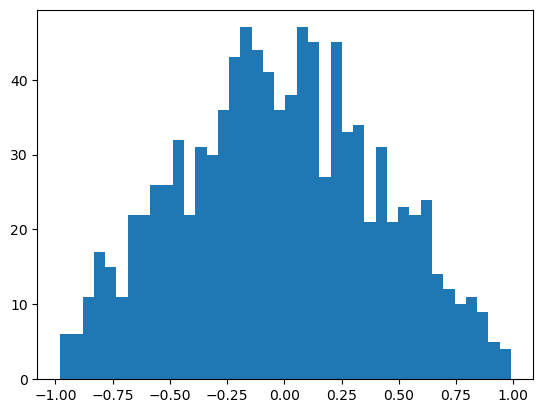

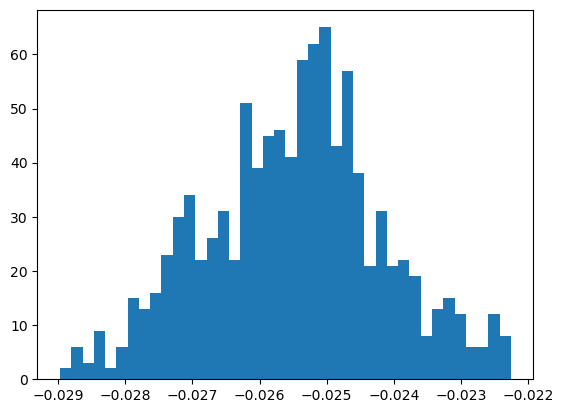

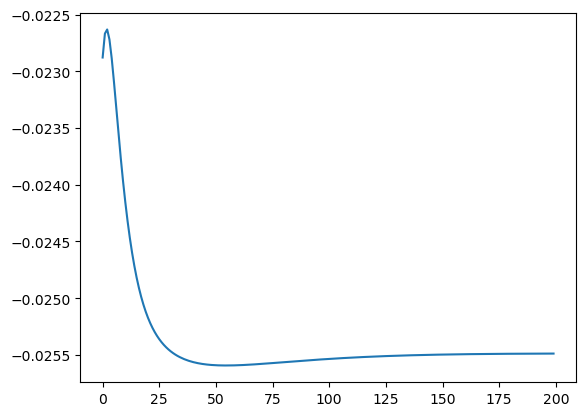

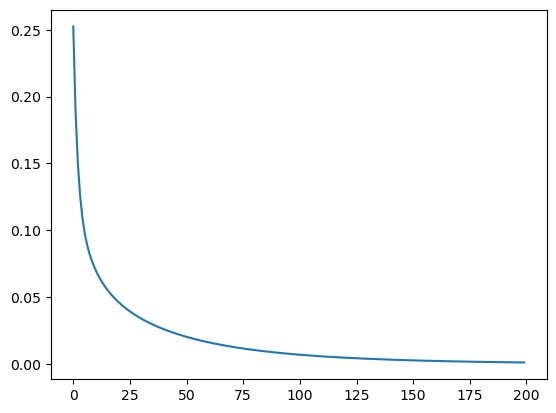

In [4]:
plt.figure()
plt.hist(no_media_no_disinfo_startcond[mask],bins = 40)
plt.show()
plt.figure()
plt.hist(no_media_no_disinfo_endcond[mask],bins = 40)
plt.show()
plt.figure()
plt.plot(np.arange(len(average_opinionresult)),average_opinionresult)
plt.show()
plt.figure()
plt.plot(np.arange(len(average_distance_to_the_mean_result)),average_distance_to_the_mean_result)
plt.show()

In [5]:
medmedier = add_media_nodes_full_normal_dist(spredningstestmatrix,100)
maskmedia = medmedier.type == 'Human'


In [6]:
medmedier.opinions, media_sim_results,media_startcond,media_endcond= simpel_simulering(medmedier,10000)
medmedier_average_opinionresult, medmedier_average_distance_to_the_mean_result = data_processing(media_sim_results,maskmedia)


Simulating: 100%|██████████| 10000/10000 [00:09<00:00, 1097.08it/s]


In [7]:
binsmedmedier = np.histogram_bin_edges(np.concatenate([media_startcond[maskmedia],media_endcond[maskmedia],no_media_no_disinfo_startcond]), bins=100)


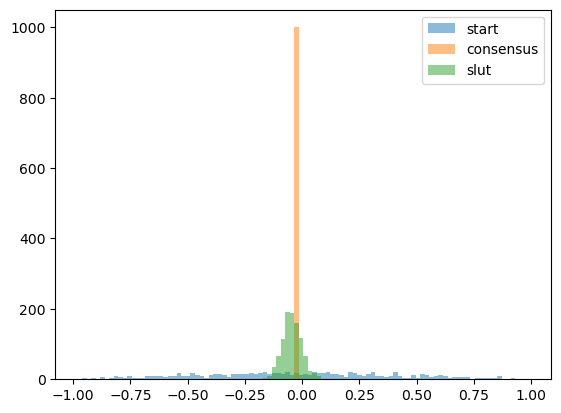

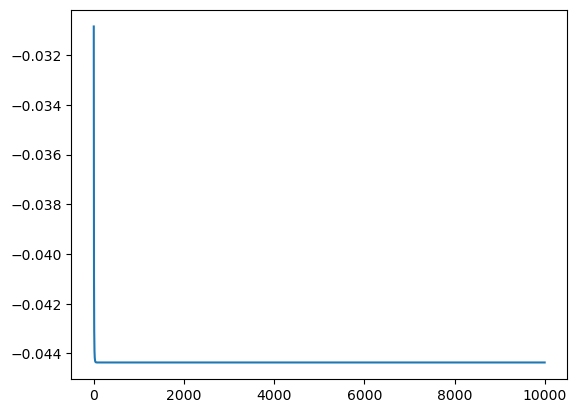

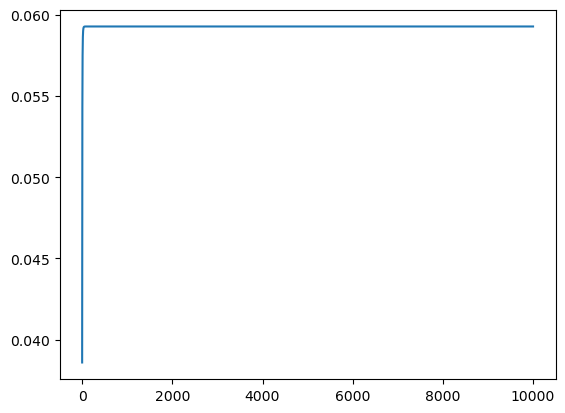

In [8]:
plt.figure()
plt.hist(no_media_no_disinfo_startcond,alpha = 0.5,bins = binsmedmedier,label = 'start')
plt.hist(media_startcond[maskmedia],alpha = 0.5,bins = binsmedmedier,label = 'consensus')
plt.hist(media_endcond[maskmedia],alpha = 0.5,bins = binsmedmedier,label = 'slut')
plt.legend()
plt.show()
plt.figure()
plt.plot(np.arange(len(medmedier_average_opinionresult)),medmedier_average_opinionresult)
plt.show()
plt.figure()
plt.plot(np.arange(len(medmedier_average_distance_to_the_mean_result)),medmedier_average_distance_to_the_mean_result)
plt.show()